# **금융경제학**

## 부록: 한센-자가나단 바운드

- 금융경제학 (박기영 저, 시그마프레스) 교재에 사용된 데이터/모형/그래프 관련 작업을 수행하는 python notebook 파일임: https://github.com/FinancialEconomicsPython/resources
- python 코드는 구글 코랩에서 사용하는 것을 기준으로 작성되었음.
- 데이터 파일이 필요한 경우 위치: https://drive.google.com/drive/folders/1sArqUZKnxWtkNtHe31iD1w-2xCVEhTj0?usp=share_link
- date: 2025/3/26

## 사전준비

1. Google colab matplotlib에서 한글 폰트 깨지는 문제 해결: 아래 (1), (2) 중 하나를 실행

  (1) koreanize_matplotlib 라이브러리 사용: 간편하나 안 될 경우 (2)를 사용
  
  (2) 폰트 다운하고 재실행

2. 구글 드라이브 mount

In [ ]:
# (1) koreanize_matplotlib 라이브러리 사용
!pip install koreanize_matplotlib
import koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 81.3 MB/s eta 0:00:00


In [ ]:
# mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import packages
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import os
import pandas_datareader as pdr
from datetime import date

import statsmodels.api as sm # module for stats models
from statsmodels.iolib.summary2 import summary_col # module for presenting stats models outputs nicely

import pandas_datareader.data as web  # module for reading datasets directly from the web
from pandas_datareader.famafrench import get_available_datasets

#sns.set_style('whitegrid')
#sns.set_style('darkgrid')
#sns.set_theme()

#sns.set(rc={'figure.figsize':(6,4)})

# for Korean fonts
plt.rcParams['axes.unicode_minus'] = False

# for preferred display
%config InlineBackend.figure_format = 'retina'   # for retina display in Mac
np.set_printoptions(precision=3, suppress=True)  # for pretty display of numpy arrays
pd.options.display.float_format = '{:,.3f}'.format
pd.options.display.max_rows = 100
pd.options.display.max_columns = 10

In [ ]:
# to plot pretty figures
%matplotlib inline

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.color'] = 'b'
plt.rcParams['axes.grid'] = True

mpl.rc('axes', labelsize=12)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
mpl.rc('font', size=12)
plt.rc('legend', fontsize=12)

# Where to save the figures: google drive를 연동해야 함
DIR = "/content/drive/MyDrive/Colab Notebooks/book_FinancialEconomics/appendix_online/"

def save_fig(fig_id, tight_layout=True):
    path = os.path.join(DIR, fig_id + ".png")
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format='png', dpi=600)

## Question 1

In this question, you will plot the Hansen-Jagannathan bounds using
the annual returns of U.S. stocks and T-bills from 1890 and 1979, which are
used by Mehra and Prescott. ps7data.xlxs contains year,
stock returns, T-bill returns, and the annual growth rate of aggregate
consumption $c_{t}/c_{t-1}$.

(a) Calculate the mean return vector of stocks and T-bills and the
covariance matrix. What is the equity premium of the period 1890-1979?

**Answer:**


In [ ]:
# 위 공유 링크(https://drive.google.com/drive/folders/1sArqUZKnxWtkNtHe31iD1w-2xCVEhTj0?usp=share_link)에서
# data_HJbound.xlsx를 다운로드 받은 후
# 사용자가 data_HJbound.xlsx를 저장한 폴더명을 아래 filepath에 입력해야 함
filepath = '/content/drive/MyDrive/Colab Notebooks/book_FinancialEconomics/data/'
filename = 'data_HJbound.xlsx'

# use header to avoid irrelevant parts
df = pd.read_excel(filepath+filename,parse_dates = True, index_col=0, header=4)
df.index.names = ['date']
df.head(3)

,stock,bills,consumption
date,,,
1890-01-01,1.044,1.063,0.972
1891-01-01,1.023,1.088,1.050
1892-01-01,1.166,1.076,1.019


In [ ]:
# convert DataFrame to matrix
Rs = np.asmatrix(df)

R = Rs[:,0]   # stock return
Rf = Rs[:,1]  # bond return (riskfree rate)
Re = R - Rf   # excess return
cons_growth = Rs[:,2] # consumption growth

mu = np.mean(Rs[:,:2], axis=0)
ERe = Re.mean()   # equity premium (average of excess return)
sigma_Re = Re.std() # std of excess returns

covx = np.cov(Rs[:,:2].T)

In [ ]:
print(f'average return of stock is {np.mean(R):.2f}')
print(f'average return of bond is {np.mean(Rf):.2f}')
print(f'equity premium is {ERe*100:.1f}%')

average return of stock is 1.07
average return of bond is 1.01
equity premium is 5.9%


In [ ]:
print('covariance matrix is given by:')
print(np.around(covx,decimals=3))

covariance matrix is given by:
[[0.027 0.001]
 [0.001 0.003]]


(b) For data on the excess return of stocks over bonds, compute the
HJ bound on the stochastic discount factor $m$. Plot the bound for $E(m)$ on
the interval [0.85 1.05].

**Answer:**

 In the case of a scalar excess return, it
becomes
\begin{equation*}
\frac{\sigma (m)}{E(m)}\geq \frac{E(R^{e})}{\sigma (R^{e})}
\end{equation*}
You can plot the bound by tracking $\sigma (m)$ by varying the values of $%
E(m)$ in the range of [0.85 1.05] after obtaining $E(R^{e})$ and $\sigma
(R^{e})$. (the figure will follow.) As you expect, it will be a straight
line.

In [ ]:
Em = np.arange(0.85,1.05,0.01)
Em = Em.reshape(len(Em),1)

sharpe_ratio = ERe/sigma_Re
#sigma_m1 = np.multiply(sharpe_ratio,Em)
sigma_m1 = sharpe_ratio*Em

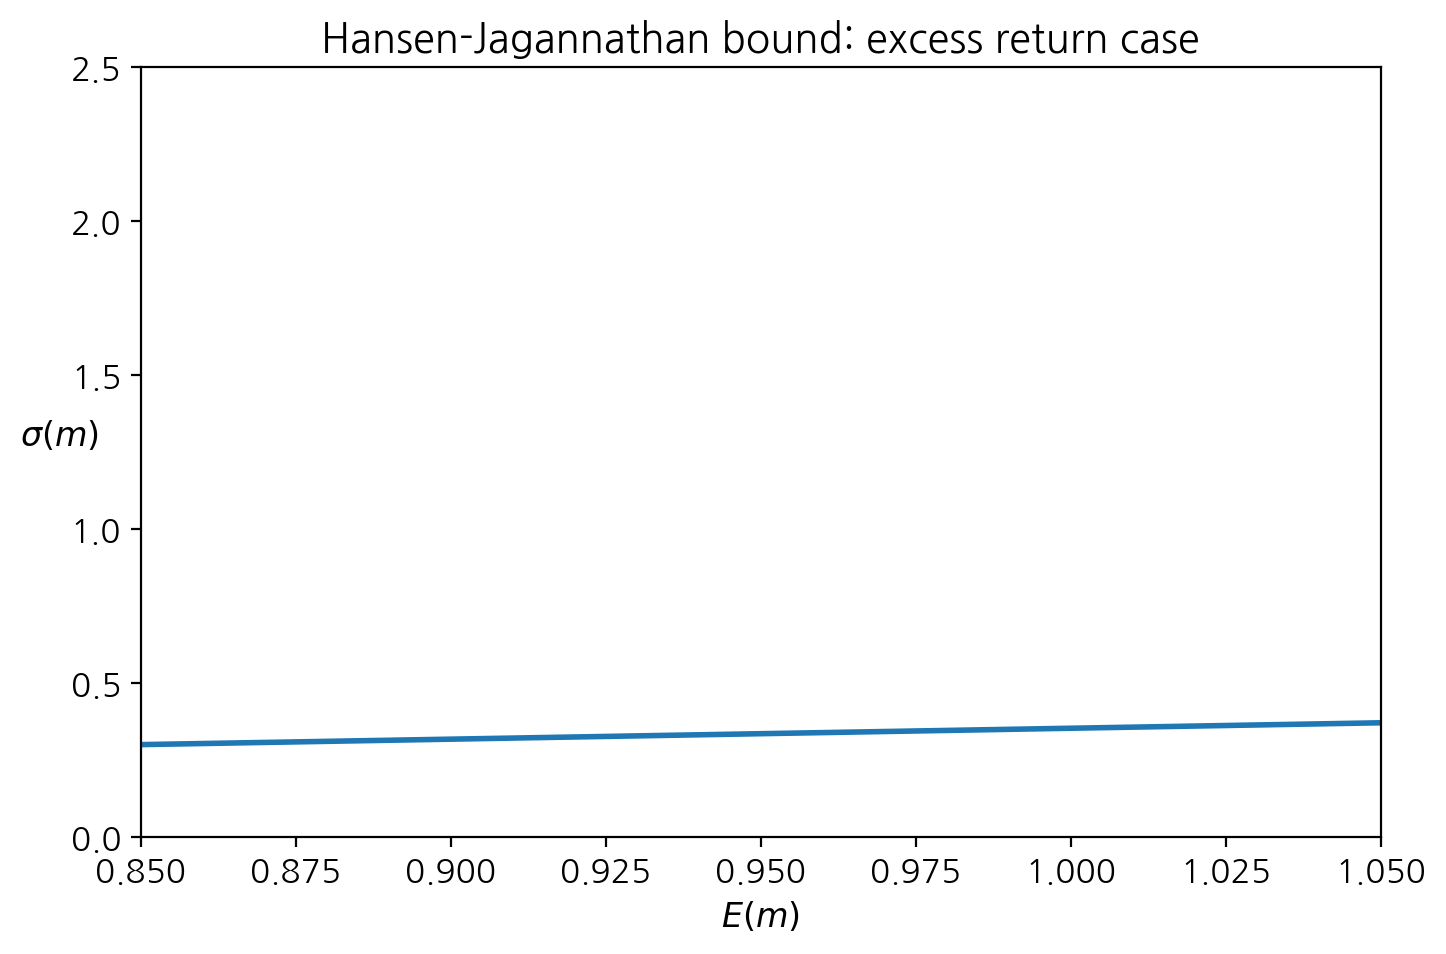

In [ ]:
plt.plot(Em, sigma_m1)
plt.xlabel('$E(m)$')
plt.ylabel(r'$\sigma (m)$', rotation = 'horizontal')
plt.title('Hansen-Jagannathan bound: excess return case')
plt.axis([0.85, 1.05, 0, 2.5])
plt.grid()

(c) Using data on $\textit{both}$ returns (stocks and bonds), compute and
plot the bound for $E(m)$ on the interval [0.85 1.05]. Plot this bound on
the same figure as you used in (b)$.$(Hint: You can use the formula given in
Case 1 of lecture note chapter 9.)

**Answer:**

See the figure below.

In [ ]:
bs = []
sigma_m2s = []

for i in Em:
  latter = np.ones((1,1))-i*mu
  b = np.linalg.inv(covx)*latter.reshape(-1,1)
  sigma_m2 = np.sqrt(b.T@covx@b)
  bs.append(b.T)
  sigma_m2s.append(sigma_m2)

In [ ]:
# resizing for matching the sizes
bs = np.array(bs).reshape(len(Em),-1)
sigma_m2s = np.array(sigma_m2s).reshape(len(Em),-1)

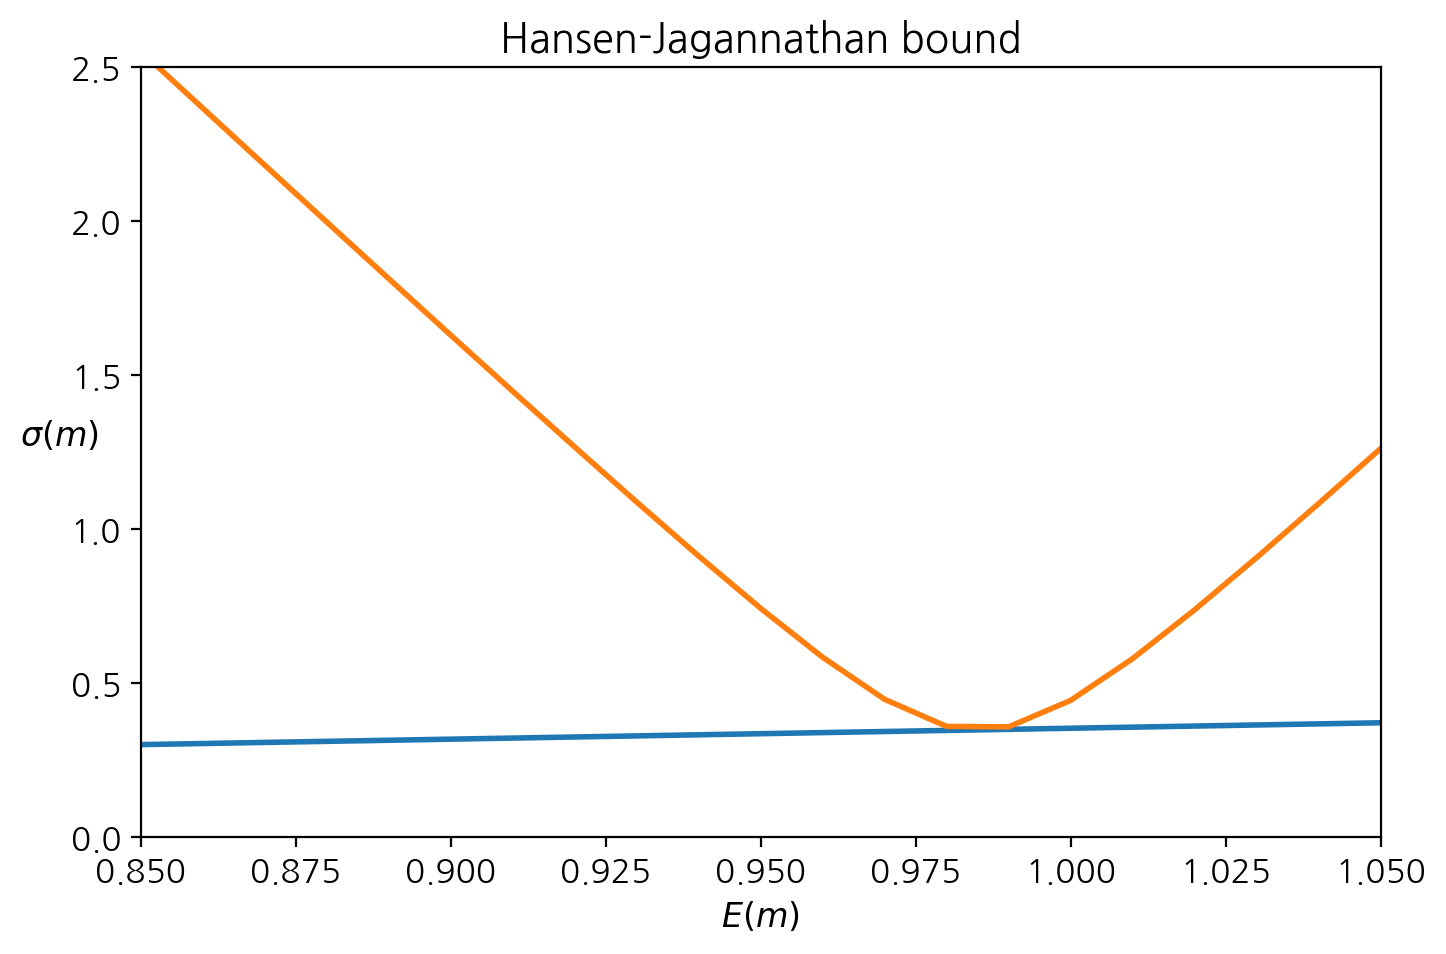

In [ ]:
plt.plot(Em, np.hstack([sigma_m1,sigma_m2s]))
plt.xlabel(r'$E(m)$')
plt.ylabel(r'$\sigma (m)$', rotation = 'horizontal')
plt.title('Hansen-Jagannathan bound')
plt.axis([0.85, 1.05, 0, 2.5])
plt.grid()

(d) Assume that $\beta =0.98$ and that $m_{t}=\beta u^{\prime
}(c_{t+1})/u^{\prime }(c_{t})$, where $u^{\prime }$ is $c^{-\gamma }$. For
the values of $\gamma =1,3,10,15,20,25$, compute the standard deviation and
mean of $m_{t}$ and locate them on the same figure. Explain the equity
premium puzzle and the riskfree rate puzzle based on your result. What is
the riskfree rate when $\gamma =15$?

**Answer:**

We have the following figure. At the
typical values of $\gamma =1\sim 3$, $\sigma (m)$ is too low for given $E(m)$
. This is the equity premium puzzle in the perspective of H-J. To increase
the volatility of SDF and put $(E(m),\sigma (m))$ into the bound, we raise $%
\gamma $. However, it makes another trouble, the riskfree rate puzzle,
because low $E(m)$ corresponds to high $R^{f}$ from $E(mR^{f})=E(m)R^{f}=1$.
For example, when $r=15$, we have too high $R^{f}=1/E(m)=1/0.88=114\%$ ($%
r^{f}=14\%$). As we increase $\gamma $ more, precautionary saving motive
dominates the intertemporal substitution motive and $(E(m),\sigma (m))$
starts floating within the bound. However, we need very high risk aversion.

In [ ]:
gamma = np.array([1, 3, 10, 15, 20, 25])
beta = 0.98

Ems = []
Sms = []

for i in gamma:
  Em1 = np.mean(beta*np.power(cons_growth, -i))
  Sm1 = np.std(beta*np.power(cons_growth,-i))
  Ems.append(Em1)
  Sms.append(Sm1)

Ems = np.array(Ems)
Sms = np.array(Sms)

Saving figure HJbound


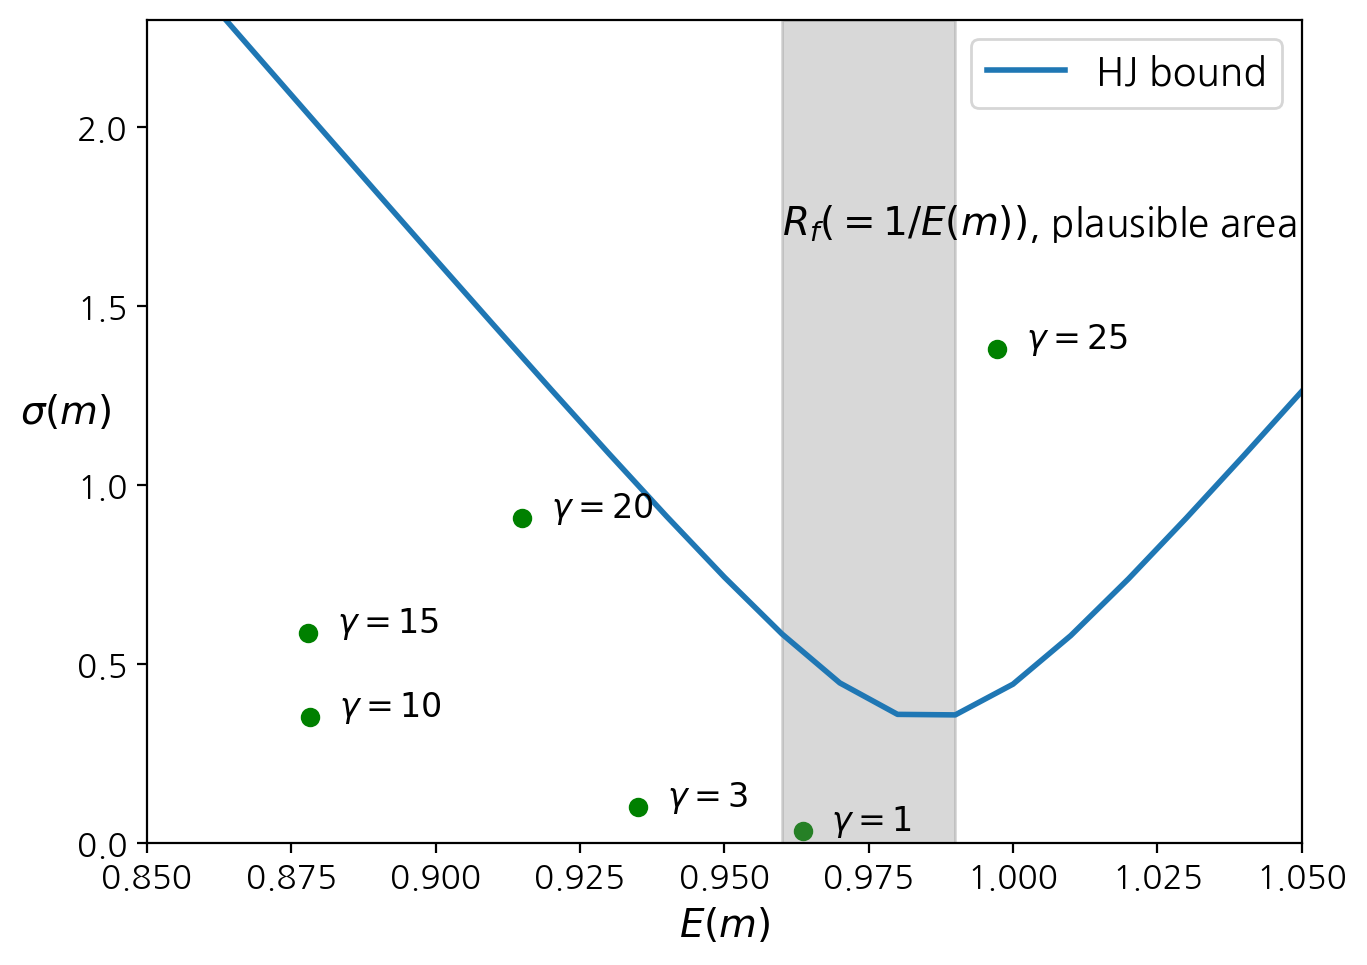

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(7,5))

ax.plot(Em, sigma_m2s, label='HJ bound')
ax.scatter(Ems, Sms, color='green')

ax.set_xlabel(r'$E(m)$',fontsize=14)
ax.set_ylabel(r'$\sigma (m)$', rotation = 'horizontal', fontsize=14)

ax.set_xlim([0.85,1.05])
ax.set_ylim([0,2.3])

ax.text(Ems[0]+0.005,Sms[0],r'$\gamma=1$', horizontalalignment='left', fontsize=12)
ax.text(Ems[1]+0.005,Sms[1],r'$\gamma=3$', horizontalalignment='left', fontsize=12)
ax.text(Ems[2]+0.005,Sms[2],r'$\gamma=10$', horizontalalignment='left', fontsize=12)
ax.text(Ems[3]+0.005,Sms[3],r'$\gamma=15$', horizontalalignment='left', fontsize=12)
ax.text(Ems[4]+0.005,Sms[4],r'$\gamma=20$', horizontalalignment='left', fontsize=12)
ax.text(Ems[5]+0.005,Sms[5],r'$\gamma=25$', horizontalalignment='left', fontsize=12)

ax.text(0.96,1.7,r"$R_f (= 1/E(m))$, plausible area", fontsize=14)

ax.axvspan(0.96,0.99,alpha=0.3, color='gray')
#ax.axvline(x=0.95, color='r', linestyle='dotted')
#ax.axvline(x=0.99, color='r', linestyle='dotted')

ax.legend(fontsize=14)
ax.grid()

save_fig('HJbound')
plt.show()